# Installation des dépendances

In [1]:
!sudo apt-get update && sudo apt-get -y install pkg-config libcairo2-dev pkg-config python3-dev

Get:1 http://security.ubuntu.com/ubuntu focal-security InRelease [114 kB]
Hit:2 http://archive.ubuntu.com/ubuntu focal InRelease                         
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease [1581 B]
Get:4 http://archive.ubuntu.com/ubuntu focal-updates InRelease [114 kB]        
Get:5 https://deb.nodesource.com/node_16.x focal InRelease [4583 B]            
Get:6 http://archive.ubuntu.com/ubuntu focal-backports InRelease [108 kB]      
Get:7 http://security.ubuntu.com/ubuntu focal-security/universe amd64 Packages [1176 kB]
Get:8 http://ppa.launchpad.net/deadsnakes/ppa/ubuntu focal InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu focal-security/restricted amd64 Packages [3253 kB]
Get:10 http://security.ubuntu.com/ubuntu focal-security/main amd64 Packages [3369 kB]
Get:11 http://security.ubuntu.com/ubuntu focal-security/multiverse amd64 Packages [29.7 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubun

In [2]:
!pip install Pillow smartcrop matplotlib tensorflow numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.1/173.1 kB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.1/347.1 kB 40.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycairo: filename=pycairo-1.25.1-cp39-cp39-linux_x86_64.whl size=328359 sha256=90d58b98e1347fff4657576556ee11f33e99f971f92ce34bf8cc9693e87ad523
  Stored in directory: /root/.cache/pip/wheels/2d/a2/6e/b7992e52e8aa207abb2da5e2331b4f794dfd549a50c4819bdb
Successfully built pycairo


# Preparation du dataset

In [3]:
%matplotlib inline

In [4]:
from pathlib import Path

import numpy as np
import tensorflow as tf
import tensorflow.keras as K

In [5]:
from pathlib import Path

path_to_dataset = Path("/datasets/bucket_s3/dataset_dojo")
path_to_cropped = path_to_dataset / "cropped"
path_to_models = Path("out/models")

img_height = 300
img_width = 300

In [6]:
import tensorflow as tf
from modules import dataload

training_dataset = dataload.create_set(path_to_cropped, "training")
validation_dataset = dataload.create_set(path_to_cropped, "validation")

class_names = training_dataset.class_names
print(f"{class_names = }")
print(f"{len(class_names) = }")

training_dataset = training_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#TODO : Ajouter un split de test pour comparer les differents types de modèles

Found 0 images in /datasets/bucket_s3/dataset_dojo/cropped.
Found 800 files belonging to 8 classes.
Using 640 files for training.
Found 0 images in /datasets/bucket_s3/dataset_dojo/cropped.
Found 800 files belonging to 8 classes.
Using 160 files for validation.
class_names = ['celtis_australis', 'juniperus_procera', 'juniperus_thurifera', 'markhamia_lutea', 'milicia_excelsa', 'pino_halepensis', 'prunus_africana', 'unknown']
len(class_names) = 8


In [7]:
import numpy as np
from tensorflow import keras as K

image_batch, _ = next(iter(training_dataset))
first_image = image_batch[0]
print(f"Initial image values interval : [{np.min(first_image)}, {np.max(first_image)}]")

normalization_layer = K.layers.Rescaling(1./255)
normalized_ds = training_dataset.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]

# Notice the pixel values are now in `[0,1]`.
print(f"Normalized image values interval : [{np.min(first_image)}, {np.max(first_image)}]")

Initial image values interval : [0.0, 248.6486358642578]
Normalized image values interval : [0.0, 0.9750927686691284]


# Modèle simple

In [8]:
from modules.model import create_model

num_classes = len(class_names)

model = create_model(
    input_shape=(img_height, img_width, 3),
    output_dim=num_classes
)

In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 300, 300, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 300, 300, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 150, 150, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)       

## Entrainement du modèle simple

In [ ]:
epochs=10
history = model.fit(
  training_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

Epoch 1/10
20/20 [==============================] - 1s 61ms/step - loss: 0.3848 - accuracy: 0.8734 - val_loss: 2.5553 - val_accuracy: 0.4000
Epoch 2/10
20/20 [==============================] - 1s 61ms/step - loss: 0.4054 - accuracy: 0.8672 - val_loss: 1.8092 - val_accuracy: 0.3750
Epoch 3/10
20/20 [==============================] - 1s 61ms/step - loss: 0.3919 - accuracy: 0.8813 - val_loss: 2.1013 - val_accuracy: 0.4375
Epoch 4/10
20/20 [==============================] - 1s 62ms/step - loss: 0.1937 - accuracy: 0.9438 - val_loss: 2.5683 - val_accuracy: 0.3938
Epoch 5/10
20/20 [==============================] - 1s 61ms/step - loss: 0.1910 - accuracy: 0.9328 - val_loss: 2.9748 - val_accuracy: 0.3375
Epoch 6/10
20/20 [==============================] - 1s 61ms/step - loss: 0.1062 - accuracy: 0.9812 - val_loss: 2.8451 - val_accuracy: 0.4125
Epoch 7/10
20/20 [==============================] - 1s 60ms/step - loss: 0.1122 - accuracy: 0.9672 - val_loss: 2.2724 - val_accuracy: 0.4125
Epoch 8/10
20

## Visualisation des métriques

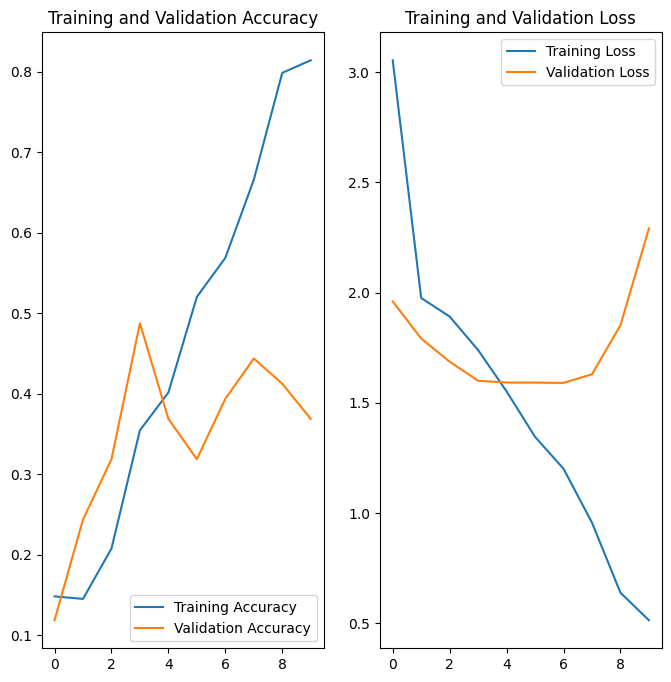

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Sauvegarde

In [13]:
from modules.model import save_model
save_model(
    model_folder=path_to_models / "simple",
    model=model,
)

# Augmentation du modele

## Illustration de la couche d'augmentation

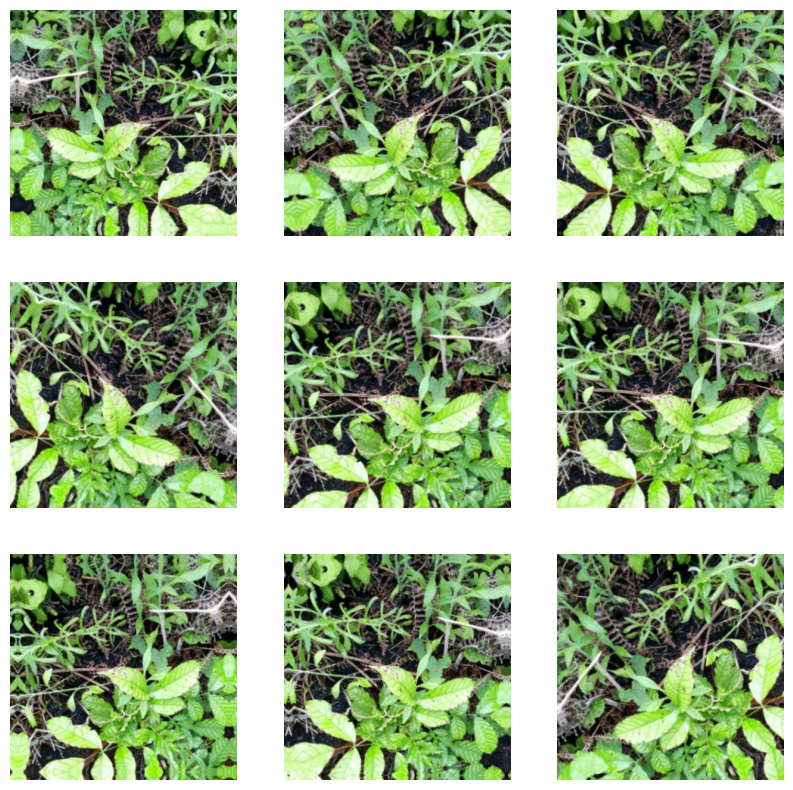

In [14]:
data_augmentation = K.Sequential([
    K.layers.RandomFlip(
        "horizontal",
        input_shape=(img_height, img_width, 3)
    ),
    K.layers.RandomRotation(0.1),
    K.layers.RandomZoom(0.1),
])

plt.figure(figsize=(10, 10))
for images, _ in training_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

## Déclaration du modèle augmenté

In [15]:
augmented_model = create_model(
    input_shape=(img_height, img_width, 3),
    output_dim=num_classes,
    augmented=True,
)

In [16]:
augmented_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [17]:
augmented_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 300, 300, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 300, 300, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 300, 300, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 150, 150, 16)     0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 150, 150, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                  

## Entrainement du modèle augmenté

In [18]:
history_aug = augmented_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/10
20/20 [==============================] - 3s 87ms/step - loss: 2.3135 - accuracy: 0.2047 - val_loss: 1.7267 - val_accuracy: 0.2500
Epoch 2/10
20/20 [==============================] - 2s 77ms/step - loss: 1.7939 - accuracy: 0.2734 - val_loss: 1.5305 - val_accuracy: 0.3187
Epoch 3/10
20/20 [==============================] - 2s 78ms/step - loss: 1.6788 - accuracy: 0.2875 - val_loss: 1.4902 - val_accuracy: 0.4313
Epoch 4/10
20/20 [==============================] - 2s 79ms/step - loss: 1.5902 - accuracy: 0.3797 - val_loss: 1.4661 - val_accuracy: 0.4250
Epoch 5/10
20/20 [==============================] - 2s 85ms/step - loss: 1.5708 - accuracy: 0.3844 - val_loss: 1.6402 - val_accuracy: 0.3375
Epoch 6/10
20/20 [==============================] - 2s 84ms/step - loss: 1.4887 - accuracy: 0.4219 - val_loss: 1.4896 - val_accuracy: 0.4000
Epoch 7/10
20/20 [==============================] - 2s 87ms/step - loss: 1.4199 - accuracy: 0.4375 - val_loss: 1.4825 - val_accuracy: 0.4125
Epoch 8/10
20

## Sauvegarde et affichage des métriques

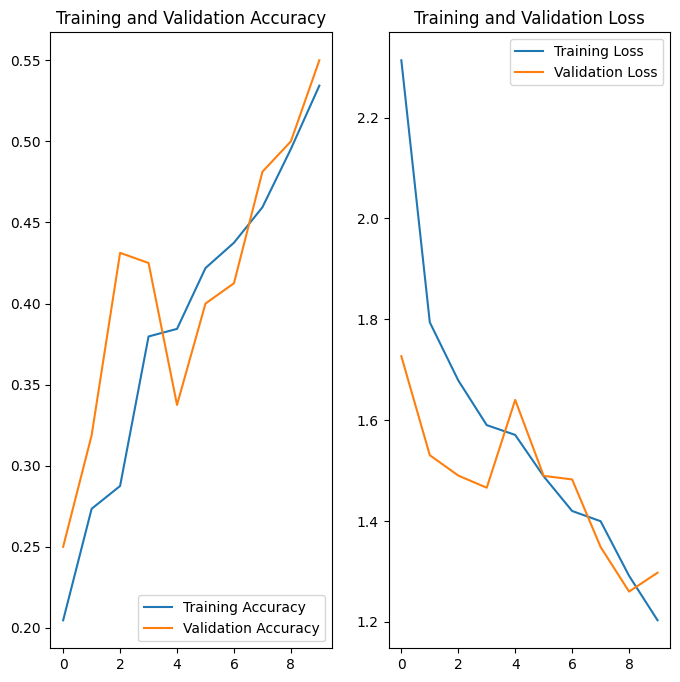

In [19]:
acc = history_aug.history['accuracy']
val_acc = history_aug.history['val_accuracy']

loss = history_aug.history['loss']
val_loss = history_aug.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Sauvegarde

In [20]:
from modules.model import save_model
save_model(
    model_folder=path_to_models / "augmented",
    model=augmented_model,
)

# Résultats

## Exemple d'inférence

1/1 [==============================] - 0s 168ms/step
This image most likely belongs to markhamia_lutea with a 50.43 percent confidence.


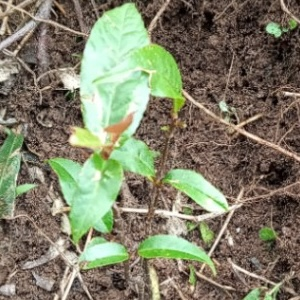

In [21]:
import os
from PIL import Image

test_file_url = "test_celtis_australis_cropped.jpeg"
im = Image.open(os.path.abspath("./" + test_file_url)) 

sunflower_path = tf.keras.utils.get_file(fname='test-file', origin='file://'+os.path.abspath("./" + test_file_url))

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

display(im)

## Comparaison du modèle simple et du modèle augmenté

In [22]:
## TODO maybe ?